<a href="https://colab.research.google.com/github/ravali217/cnn/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import random


In [13]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])
print("Training image shape:", x_train.shape[1:])
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Number of training images: 60000
Number of testing images: 10000
Training image shape: (28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


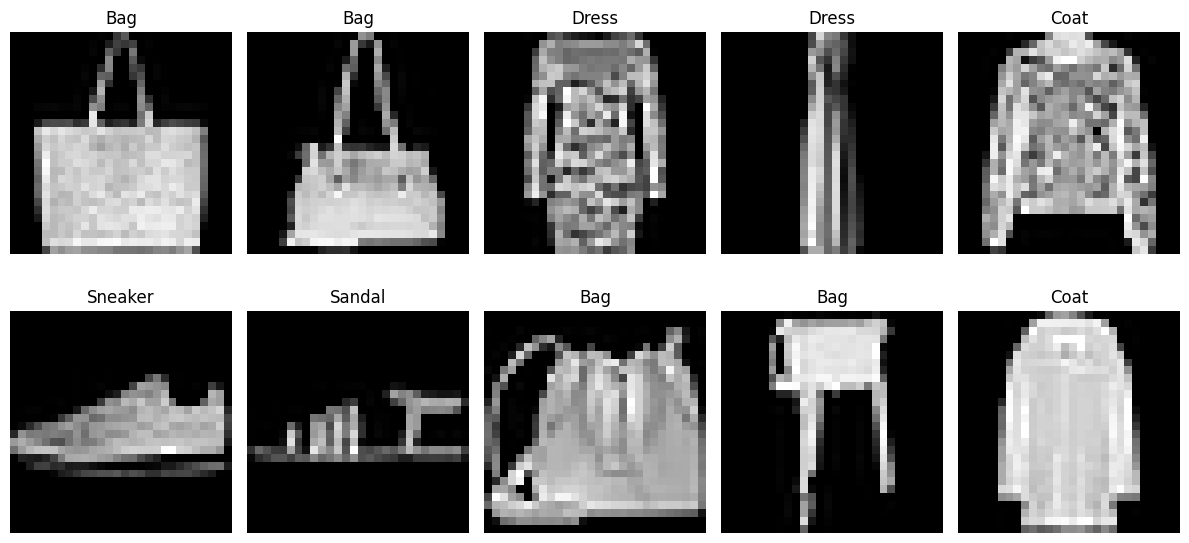

In [14]:
plt.figure(figsize=(12, 6))
random_indices = random.sample(range(len(x_train)), 10)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [17]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Normalize pixel values from 0-255 to 0-1

In [18]:

# Reshape to CNN format: (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [19]:

print("After reshaping:")
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

After reshaping:
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [21]:
# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("y_train one-hot shape:", y_train_cat.shape)
print("y_test one-hot shape:", y_test_cat.shape)


y_train one-hot shape: (60000, 10)
y_test one-hot shape: (10000, 10)


In [22]:
# Count number of images in each class
class_counts = np.bincount(y_train)

print("\nClass distribution in training set:")
for i, count in enumerate(class_counts):
    print(f"{class_names[i]}: {count}")


Class distribution in training set:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


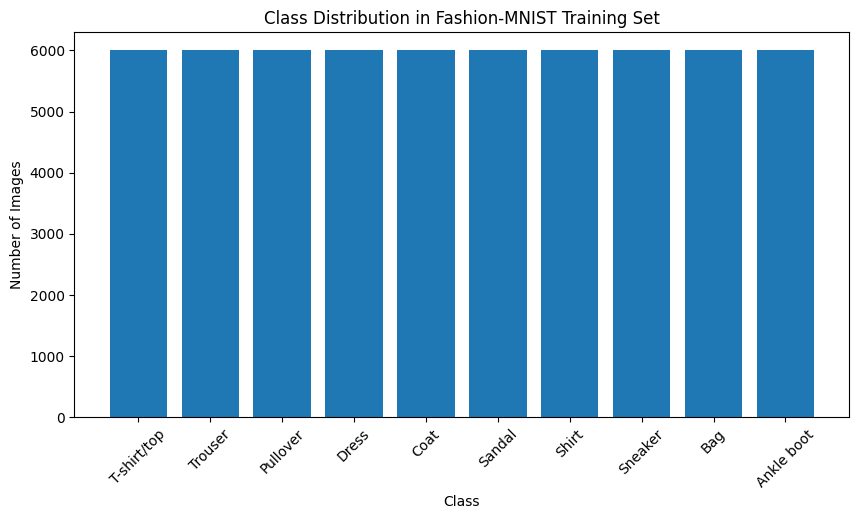

In [23]:
# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution in Fashion-MNIST Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Task 4 — Build First CNN Architecture


model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.4457 - loss: 1.5216 - val_accuracy: 0.6985 - val_loss: 0.7505
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.7320 - loss: 0.7125 - val_accuracy: 0.7576 - val_loss: 0.6384
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step - accuracy: 0.7676 - loss: 0.6185 - val_accuracy: 0.7879 - val_loss: 0.5709
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.7861 - loss: 0.5731 - val_accuracy: 0.8008 - val_loss: 0.5338
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8045 - loss: 0.5330 - val_accuracy: 0.8090 - val_loss: 0.5179
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.8126 - loss: 0.5014 - val_accuracy: 0.8203 - val_loss: 0.4934
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8242 - loss: 0.4786 - val_accuracy: 0.8246 - val_loss: 0.4692
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.8276 - loss: 0.4655 - 

In [27]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8281 - loss: 0.4605
Test Loss: 0.4610
Test Accuracy: 0.8243


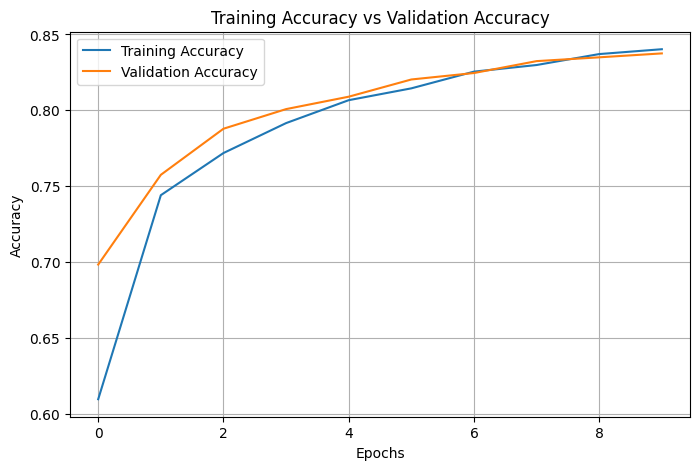

In [28]:
#Plot training accuracy vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


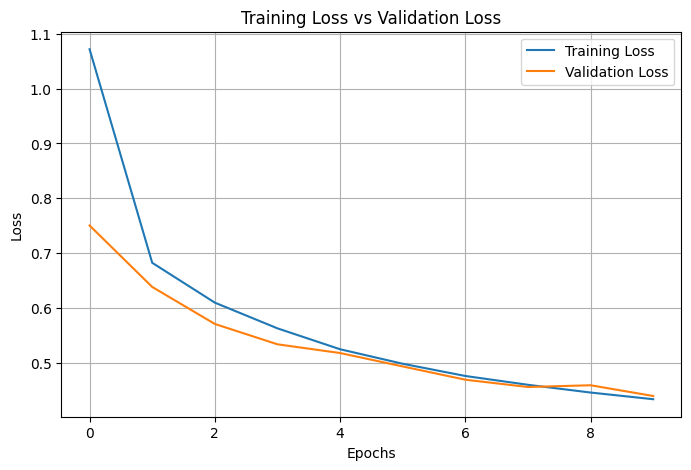

In [29]:
#Plot training loss vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [30]:
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_cat[:5], axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


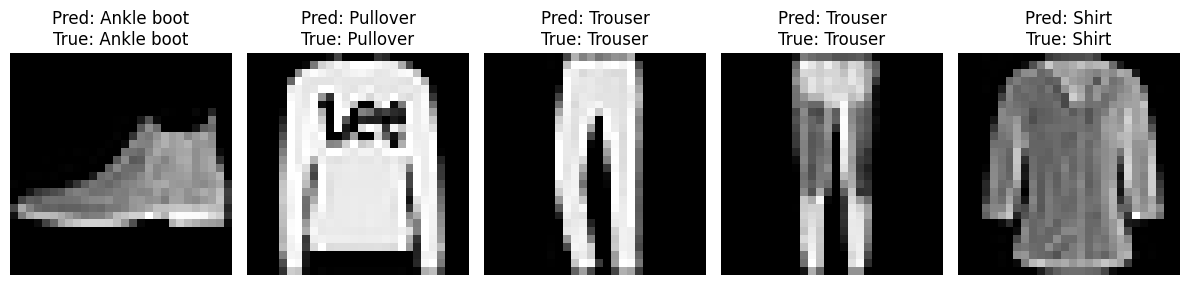

In [31]:
plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict all test images
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)





313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


In [33]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[783   1  16  69   4   3 112   0  12   0]
 [  2 950   1  38   3   1   3   0   2   0]
 [ 14   1 702  20  87   2 165   0   9   0]
 [ 20  10  17 887  17   0  46   0   3   0]
 [  0   1 124  52 528   0 290   0   5   0]
 [  0   0   0   2   0 924   0  53   2  19]
 [160   1 102  40  38   0 638   0  21   0]
 [  0   0   0   0   0  21   0 942   0  37]
 [  3   1  16   8   2   6  18   5 940   1]
 [  0   0   0   0   0   8   1  41   1 949]]


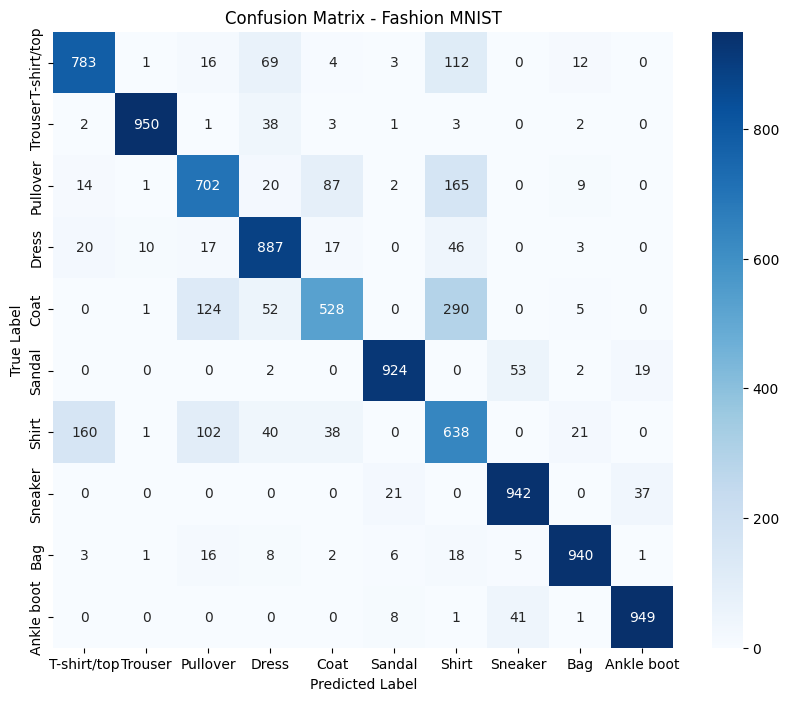

In [34]:
# Visualize confusion matrix using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Fashion MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Improved CNN model (Model 2)
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile model 2
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history2 = model2.fit(
    x_train,
    y_train_cat,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 270s 360ms/step - accuracy: 0.7058 - loss: 0.7702 - val_accuracy: 0.8068 - val_loss: 0.4981
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 313s 349ms/step - accuracy: 0.7802 - loss: 0.5950 - val_accuracy: 0.8362 - val_loss: 0.4533


In [38]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test_cat, verbose=0)

print("Model 2 Test Loss:", test_loss2)
print("Model 2 Test Accuracy:", test_accuracy2)


Model 2 Test Loss: 0.4699791967868805
Model 2 Test Accuracy: 0.8339999914169312


In [39]:
print("Model 1 Test Accuracy:", test_accuracy)
print("Model 2 Test Accuracy:", test_accuracy2)

if test_accuracy2 > test_accuracy:
    print("Model 2 performed better than Model 1.")
elif test_accuracy2 < test_accuracy:
    print("Model 1 performed better than Model 2.")
else:
    print("Both models performed equally.")


Model 1 Test Accuracy: 0.8242999911308289
Model 2 Test Accuracy: 0.8339999914169312
Model 2 performed better than Model 1.


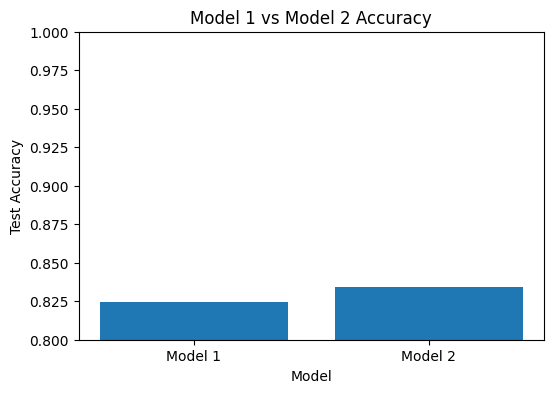

In [40]:
models = ['Model 1', 'Model 2']
accuracies = [test_accuracy, test_accuracy2]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.title("Model 1 vs Model 2 Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0.8, 1.0)
plt.show()


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Predict on test set using Model 2
y_pred_probs = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Find wrongly predicted indices
wrong_indices = np.where(y_pred_classes != y_true_classes)[0]

print("Number of wrongly predicted images:", len(wrong_indices))


313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step
Number of wrongly predicted images: 1660


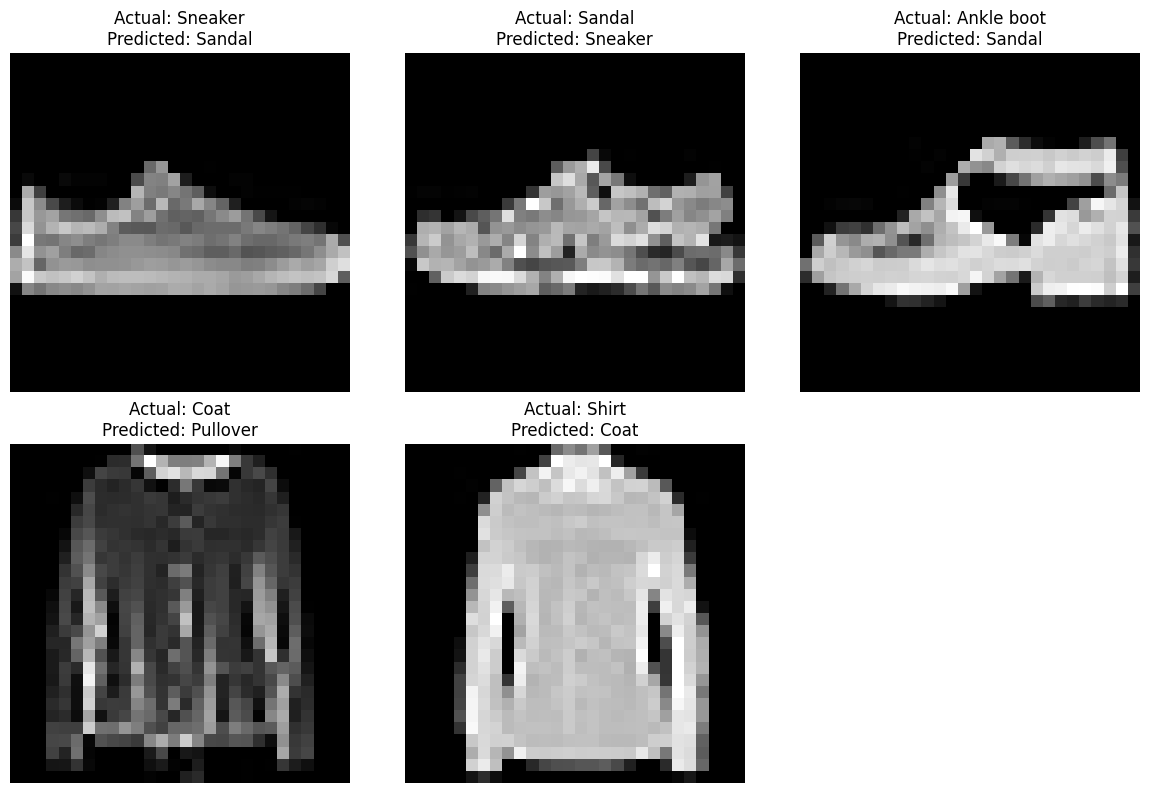

In [42]:
plt.figure(figsize=(12, 8))

for i in range(5):
    idx = wrong_indices[i]
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {class_names[y_true_classes[idx]]}\nPredicted: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [43]:
for i in range(5):
    idx = wrong_indices[i]
    print(f"Image {i+1}:")
    print("Actual Label   :", class_names[y_true_classes[idx]])
    print("Predicted Label:", class_names[y_pred_classes[idx]])
    print("-" * 30)


Image 1:
Actual Label   : Sneaker
Predicted Label: Sandal
------------------------------
Image 2:
Actual Label   : Sandal
Predicted Label: Sneaker
------------------------------
Image 3:
Actual Label   : Ankle boot
Predicted Label: Sandal
------------------------------
Image 4:
Actual Label   : Coat
Predicted Label: Pullover
------------------------------
Image 5:
Actual Label   : Shirt
Predicted Label: Coat
------------------------------


313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step
Number of wrongly predicted images: 1660


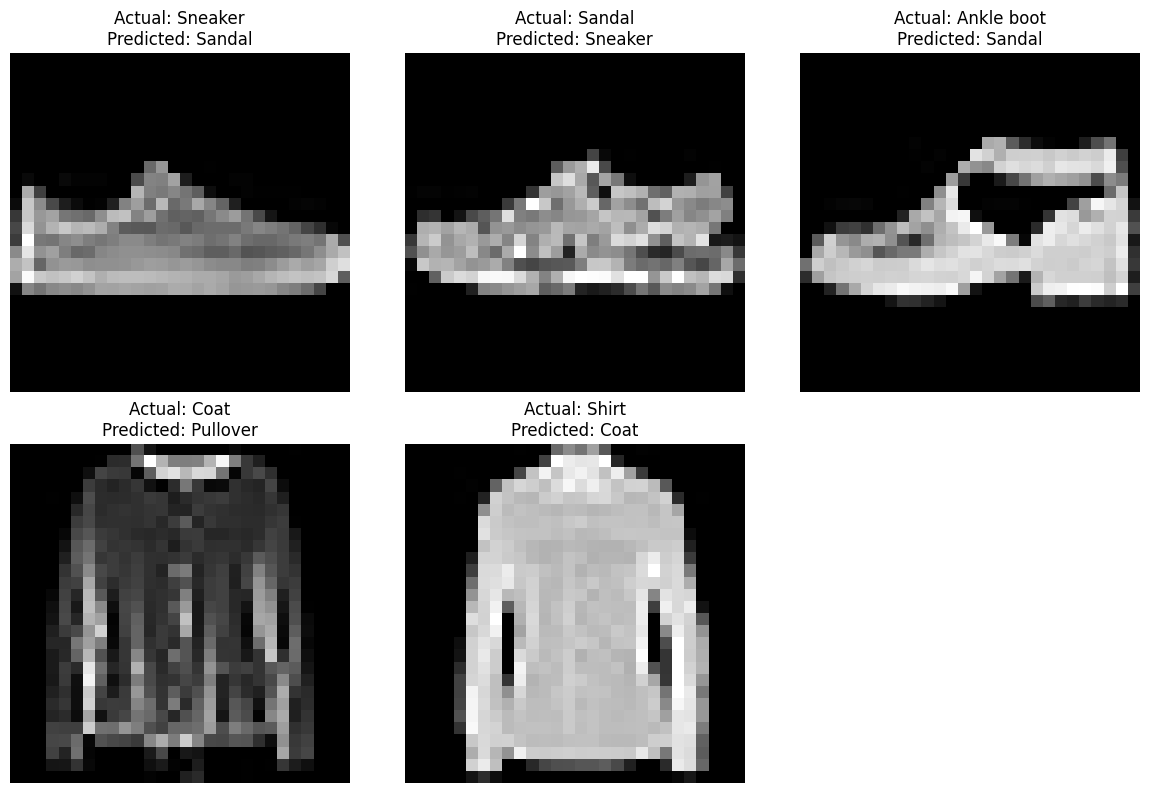

Image 1:
Actual Label   : Sneaker
Predicted Label: Sandal
------------------------------
Image 2:
Actual Label   : Sandal
Predicted Label: Sneaker
------------------------------
Image 3:
Actual Label   : Ankle boot
Predicted Label: Sandal
------------------------------
Image 4:
Actual Label   : Coat
Predicted Label: Pullover
------------------------------
Image 5:
Actual Label   : Shirt
Predicted Label: Coat
------------------------------


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Predict all test images
y_pred_probs = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Find misclassified images
wrong_indices = np.where(y_pred_classes != y_true_classes)[0]

print("Number of wrongly predicted images:", len(wrong_indices))

# Display 5 wrongly predicted images
plt.figure(figsize=(12, 8))

for i in range(5):
    idx = wrong_indices[i]
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {class_names[y_true_classes[idx]]}\nPredicted: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print labels
for i in range(5):
    idx = wrong_indices[i]
    print(f"Image {i+1}:")
    print("Actual Label   :", class_names[y_true_classes[idx]])
    print("Predicted Label:", class_names[y_pred_classes[idx]])
    print("-" * 30)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


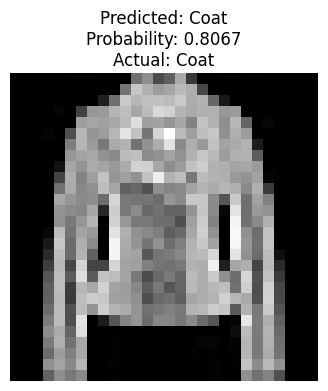

Predicted Label      : Coat
Prediction Confidence: 80.67 %
Actual Label         : Coat


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Select a random test image
random_index = random.randint(0, len(x_test) - 1)
random_image = x_test[random_index]
true_label = np.argmax(y_test_cat[random_index])

# Predict
prediction = model2.predict(random_image.reshape(1, 28, 28, 1))
predicted_class = np.argmax(prediction)
predicted_probability = np.max(prediction)

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(random_image.reshape(28, 28), cmap='gray')
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Probability: {predicted_probability:.4f}\n"
    f"Actual: {class_names[true_label]}"
)
plt.axis('off')
plt.show()

# Print result
print("Predicted Label      :", class_names[predicted_class])
print("Prediction Confidence:", round(float(predicted_probability) * 100, 2), "%")
print("Actual Label         :", class_names[true_label])


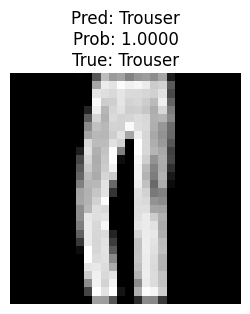

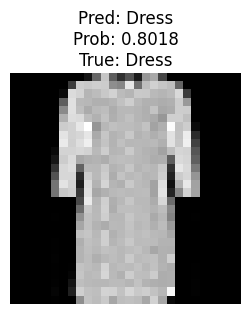

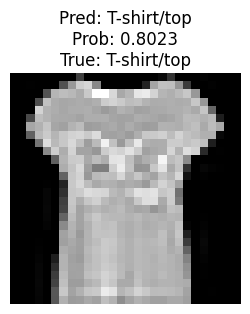

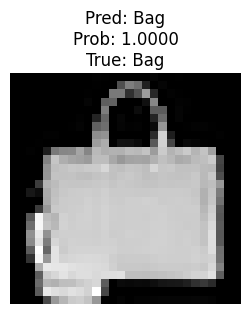

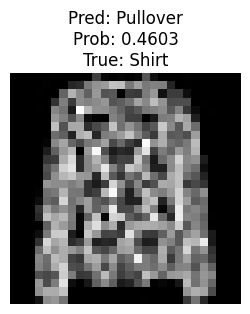

In [46]:
for _ in range(5):
    random_index = random.randint(0, len(x_test) - 1)
    random_image = x_test[random_index]
    true_label = np.argmax(y_test_cat[random_index])

    prediction = model2.predict(random_image.reshape(1, 28, 28, 1), verbose=0)
    predicted_class = np.argmax(prediction)
    predicted_probability = np.max(prediction)

    plt.figure(figsize=(3, 3))
    plt.imshow(random_image.reshape(28, 28), cmap='gray')
    plt.title(
        f"Pred: {class_names[predicted_class]}\n"
        f"Prob: {predicted_probability:.4f}\n"
        f"True: {class_names[true_label]}"
    )
    plt.axis('off')
    plt.show()
